# S6-5 ボラティリティサーフェスとSABR入門

## 学習目標

- スワップションのボラティリティキューブ（満期×テナー×ストライク）の構造と、
  なぜ単一のボラティリティでは足りないのかを説明できる
- スマイル・スキューが何を表す市場の値付けかを理解し、両者を区別できる
- SABR モデルの4パラメータ $(\alpha,\beta,\rho,\nu)$ が、それぞれスマイルの
  どの形（水準・傾き・曲率・バックボーン）を動かすかを直感で言える
- Hagan 近似式を自分で実装し、`bondlab.pricing.sabr_vol` および QuantLib と
  機械精度で一致することを確認できる
- 既知パラメータで生成したスマイルから、フィットで係数を復元できる
- Hagan 近似が壊れる領域（低金利・長期・極端な行使）を、無裁定条件の破れとして
  数値で確認できる
- $\beta$ を固定してから残りをキャリブレーションする実務手順の理由（識別問題と
  外挿の安定性）を説明できる

## 実務での位置づけ（ファンドはどう稼ぐか）

ボラティリティサーフェス（キューブ）は、レートデスクのオプション帳を値付けし在庫リスクを測るための共通言語です。市場でクォートされるのは満期×テナー×ストライクの飛び飛びの格子にすぎず、実際の顧客取引はその格子の間や外側のストライク・満期で起きます。SABR はこの観測点を4つのパラメータへ要約し、格子を滑らかに補間・外挿する要約器です。デスクは各セルの SABR パラメータでスマイル全体を保持し、任意のスワップション・キャップレットを整合的に値付けします。ここで実装した Hagan 近似と、既知パラメータで生成したスマイルからのフィットは、そのキャリブレーション作業そのものです。

サーフェスが収益に効くのは二つの経路です。第一に、マーケットメイクではオフ ATM のストライクを一貫した値付けで即座にクォートできるかがスプレッド収益を左右します。スマイル・スキューの形を取り違えると、裾のストライクで不利な約定を重ね、ヘッジしきれないベガ・ガンマを抱えます。第二に、スキュー（負のバックボーン、右下がり）はコーラブル債・MBS のオプション評価やスワップションのボラ RV の入力になります。あるセルのスマイルが歴史的・モデル的に割高・割安と見れば、リスクリバーサルやバタフライでスキュー・カーバチャそのものを売買し、デルタ・ベガを中立にしてゆがみの収束を取ります。

$\beta$ を固定してから残りをキャリブレーションする実務手順は、識別問題と外挿の安定性という運用上の要請から来ています。$\beta$ と $\rho$ が ATM 近傍で似た効き方をして同時推定が不安定になるため、$\beta$ を先に固定してバックボーンの型を決め、日々のフィットを安定させます。Hagan 近似が低金利・長期・極端な行使で無裁定条件を破る領域を数値で把握しておくことは、リスク管理上必須です。近似の破れをそのまま値付け・リスク集計に流すと、裾のオプションで評価と感応度が歪み、モデルバリデーション（S5-5）はこの適用範囲と代替（無裁定 SABR 等）の要否を独立に検証します。


## 理論

### ボラティリティキューブ（volatility cube）

スワップション市場は、1本のボラティリティでは記述できません。値付けに必要な軸が
三つあるためです。

| 軸 | 意味 | 例 |
|---|---|---|
| 満期（expiry） | オプションの行使までの年数 | 1年, 5年, 10年 |
| テナー（tenor） | 行使後に始まる原スワップの年限 | 2年, 5年, 10年 |
| ストライク（strike） | 行使レート。ATM からの乖離で並べる | ATM±50bp, ±100bp |

この三次元の格子に観測ボラティリティを並べたものを **ボラティリティキューブ** と
呼びます。満期×テナーの1つのセル（例：5年満期×10年テナー、いわゆる "5y10y"）を
固定してストライク方向に切ると、後述のスマイルが現れます。逆に ATM だけを並べて
満期×テナー平面を見たものが **ATM ボラティリティ行列** です。

キューブが必要になるのは、フォワードスワップレート $F$ が満期・テナーごとに異なり、
その分布の裾（テールリスク）も市場が別々に値付けしているからです。デスクは各セルの
スマイルを少数のパラメータへ要約し、格子の間や外側を補間・外挿します。その要約器の
標準が SABR です。

### スマイルとスキュー（smile / skew）

満期×テナーを固定し、行使レート $K$ に対するインプライドボラティリティ
$\sigma_{\mathrm{impl}}(K)$ をプロットしたものが **スマイル** です。Black モデルが
正しければ $\sigma_{\mathrm{impl}}(K)$ は $K$ によらず水平になるはずですが、実際は
ATM を谷とする曲線になります。市場が正規分布より裾を厚く（ファットテール）値付け
しているためです。

- **スマイル（smile）**：ATM の両側でボラティリティが持ち上がる曲率成分。裾の厚さ、
  すなわち大きく動く確率の値付けを表します。$K$ に関する二階の効き。
- **スキュー（skew）**：ATM 近傍でのスマイルの傾き。低ストライク側が高い（右下がり）か、
  高ストライク側が高いかの非対称性を表します。$K$ に関する一階の効き。

金利では、レートが下がる局面ほどボラティリティが上がる関係（負のバックボーン）から、
低ストライク側が高い右下がりのスキューが典型です。

### SABR モデルの直感（4パラメータの役割）

SABR（Stochastic Alpha Beta Rho）は、フォワード $F_t$ とその瞬間ボラティリティ
$\alpha_t$ を確率微分方程式で同時に動かすモデルです。

$$
dF_t = \alpha_t\, F_t^{\beta}\, dW_t^{1}, \qquad
d\alpha_t = \nu\, \alpha_t\, dW_t^{2}, \qquad
dW_t^{1} dW_t^{2} = \rho\, dt .
$$

4パラメータの役割は次のとおりです。

| 記号 | 名前 | 動かすもの | 直感 |
|---|---|---|---|
| $\alpha$ | 水準ボラティリティ | スマイル全体の高さ | ほぼ ATM ボラを決める |
| $\beta$ | CEV 指数 | バックボーンの型 | $F$ が動いたとき ATM ボラがどう動くか（0:正規的, 1:対数正規的） |
| $\rho$ | 相関 | スキュー（傾き） | 負なら右下がり、フォワードとボラの連動 |
| $\nu$ | ボラのボラ（vol-of-vol） | スマイルの曲率 | 大きいほど両裾が持ち上がる |

$\beta$ は **バックボーン**（backbone、ATM ボラと $F$ の水準の関係）を決めます。
$\beta=1$ なら ATM ボラは $F$ が動いてもほぼ一定（対数正規的）、$\beta=0$ なら
$F$ の低下とともに対数正規ボラが上がる（正規的）挙動になります。$\rho$ と $\beta$ は
どちらもスキューに効くため、両者を同時にキャリブレーションすると識別が甘くなります
（後述）。

### Hagan 近似式（Hagan's approximation）

上の SDE には閉形式の解がありません。Hagan ほか（2002）は、$\nu$ と満期 $T$ が小さい
という漸近展開で、SABR 価格を Black モデルへ写像する **インプライドボラティリティの
近似式** を導きました。$F\neq K$ のとき対数正規ボラは

$$
\sigma_{\mathrm{impl}}(K)=
\frac{\alpha}{(FK)^{(1-\beta)/2}\,\bigl[1+\frac{(1-\beta)^2}{24}\log^2\frac{F}{K}
+\frac{(1-\beta)^4}{1920}\log^4\frac{F}{K}\bigr]}
\cdot\frac{z}{x(z)}\cdot\bigl[1+A\,T\bigr],
$$

$$
z=\frac{\nu}{\alpha}(FK)^{(1-\beta)/2}\log\frac{F}{K},\qquad
x(z)=\log\!\frac{\sqrt{1-2\rho z+z^2}+z-\rho}{1-\rho},
$$

$$
A=\frac{(1-\beta)^2}{24}\frac{\alpha^2}{(FK)^{1-\beta}}
+\frac{1}{4}\frac{\rho\beta\nu\alpha}{(FK)^{(1-\beta)/2}}
+\frac{2-3\rho^2}{24}\nu^2 .
$$

ATM（$F=K$）では $z/x(z)\to 1$ となり、

$$
\sigma_{\mathrm{ATM}}=\frac{\alpha}{F^{1-\beta}}\Bigl[1+A\,T\Bigr].
$$

この式のおかげで、各セルの観測スマイルへ $(\alpha,\rho,\nu)$（$\beta$ は固定）を
最小二乗でフィットするだけで、滑らかな補間・外挿器が得られます。

### Hagan 近似が壊れる領域

近似は「$\nu$ 小・$T$ 小・行使が ATM 近傍」で精度が高く、そこから外れると崩れます。

- **低金利・負金利**：$\beta<1$ では $(FK)^{(1-\beta)/2}$ が $K\to 0$ で 0 に近づき、
  式が発散します。低い $F$ とワイドな行使では、後述の Breeden–Litzenberger 密度が
  **負** になり無裁定を破ります（バタフライ・アービトラージ）。
- **長期満期**：$1+A\,T$ という一次の $T$ 展開は $T$ が大きいと誤差が積み上がります。
  $A\,T$ が無視できない大きさになり、近似の前提から外れます。
- **極端な行使**：$\log(F/K)$ が大きいディープ ITM/OTM では高次項が効き、実測から
  乖離します。

実務では、低金利では対数正規 SABR ではなく **シフト付き SABR**（$F\to F+s$）や
**正規（Bachelier）SABR** を使い、負の行使を許します。本 notebook では素の Hagan
対数正規版を扱い、壊れる様子を密度で可視化します。

**数値例**：ATM 式 $\sigma_{\text{ATM}}=\dfrac{\alpha}{F^{1-\beta}}\bigl[1+A\,T\bigr]$ に $\alpha=0.02,\ \beta=0.5,\ F=3.0\%,\ T=5,\ \rho=-0.3,\ \nu=0.4$ を入れると、$\dfrac{\alpha}{F^{1-\beta}}=\dfrac{0.02}{\sqrt{0.03}}=0.1155$、補正 $A=0.00994$ で $\sigma_{\text{ATM}}=0.1155\times(1+0.00994\times5)=0.1212=12.12\%$ です。

**数値例**：同じパラメータで行使 $K=2.0\%$（ITM 側）のインプライドボラは $\sigma_{\text{impl}}=17.63\%$ と ATM の $12.12\%$ より高く、$\rho<0$ による右下がりのスキューが数値で現れます。


## スクラッチ実装

Hagan 近似式を自分で実装し、`bondlab.pricing.sabr_vol` と一致することを確認します。
次に $(\alpha,\beta,\rho,\nu)$ の感応度を図示し、最後に既知パラメータで作った
スマイルへ最小二乗でフィットして係数を復元します。

### 使用する自作関数

| 関数 | 引数 | 返り値 | 役割 |
|---|---|---|---|
| `my_sabr_vol(F, K, T, alpha, beta, rho, nu)` | フォワード, 行使, 満期, 4パラメータ | 対数正規ボラ | Hagan 近似式のスクラッチ実装 |
| `sabr_smile(F, Ks, T, alpha, beta, rho, nu)` | 行使配列を受ける | ボラ配列 | 行使方向にベクトル化した呼び出し |
| `fit_sabr(F, Ks, vols, T, beta)` | 観測スマイルと固定 $\beta$ | $(\alpha,\rho,\nu)$ | 最小二乗キャリブレーション |
| `bl_density(F, Ks, T, vol_fn, df)` | フォワード, 行使格子, ボラ関数 | 密度配列 | Breeden–Litzenberger でリスク中立密度を数値算出 |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as _fm
for _f in ["Hiragino Sans", "Yu Gothic", "Meiryo", "IPAexGothic", "Noto Sans CJK JP", "Noto Sans JP", "TakaoPGothic", "IPAPGothic"]:
    if any(_f == _n.name for _n in _fm.fontManager.ttflist):
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False
from scipy.optimize import least_squares

import bondlab
from bondlab.pricing import sabr_vol, black76

np.random.seed(0)
print("bondlab version:", bondlab.__version__)


def my_sabr_vol(F, K, T, alpha, beta, rho, nu):
    """Hagan(2002) 近似による SABR の対数正規インプライドボラ（スクラッチ実装）。

    F=F フォワード, K=行使, T=満期, alpha=水準ボラ, beta=CEV指数,
    rho=相関, nu=ボラのボラ。F=K の ATM は別式で扱う。
    """
    if abs(F - K) < 1e-12:  # ATM 極限（z/x(z)→1）
        term_atm = (((1 - beta) ** 2 / 24) * alpha ** 2 / F ** (2 - 2 * beta)
                    + 0.25 * rho * beta * nu * alpha / F ** (1 - beta)
                    + (2 - 3 * rho ** 2) / 24 * nu ** 2)
        return alpha / F ** (1 - beta) * (1 + term_atm * T)
    log_fk = np.log(F / K)
    fk_beta = (F * K) ** ((1 - beta) / 2)
    z = (nu / alpha) * fk_beta * log_fk
    x = np.log((np.sqrt(1 - 2 * rho * z + z ** 2) + z - rho) / (1 - rho))
    denom = fk_beta * (1
                       + (1 - beta) ** 2 / 24 * log_fk ** 2
                       + (1 - beta) ** 4 / 1920 * log_fk ** 4)
    prefactor = alpha / denom * (z / x)
    correction = (((1 - beta) ** 2 / 24) * alpha ** 2 / fk_beta ** 2
                  + 0.25 * rho * beta * nu * alpha / fk_beta
                  + (2 - 3 * rho ** 2) / 24 * nu ** 2)
    return prefactor * (1 + correction * T)


def sabr_smile(F, Ks, T, alpha, beta, rho, nu):
    """行使配列 Ks に対して my_sabr_vol をベクトル化して返す。"""
    return np.array([my_sabr_vol(F, float(K), T, alpha, beta, rho, nu) for K in Ks])

bondlab version: 0.0.1


### 自作実装と `bondlab.pricing.sabr_vol` の一致確認

ATM・OTM・ITM の三点で突き合わせ、機械精度で一致することを `assert` で守ります。

In [2]:
F, T = 0.030, 5.0
alpha_t, beta_t, rho_t, nu_t = 0.020, 0.5, -0.30, 0.40

check_strikes = [0.020, 0.030, 0.045]  # ITM, ATM, OTM
print(f"{'K':>8} {'自作':>14} {'bondlab':>14} {'|差|':>12}")
for K in check_strikes:
    mine = my_sabr_vol(F, K, T, alpha_t, beta_t, rho_t, nu_t)
    lib = sabr_vol(F, K, T, alpha_t, beta_t, rho_t, nu_t)
    print(f"{K:8.3f} {mine:14.10f} {lib:14.10f} {abs(mine - lib):12.2e}")
    assert abs(mine - lib) < 1e-13

print("\n自作 Hagan 実装は bondlab.pricing.sabr_vol と機械精度で一致しました")

       K             自作        bondlab          |差|
   0.020   0.1763482945   0.1763482945     0.00e+00
   0.030   0.1212090145   0.1212090145     0.00e+00
   0.045   0.1217331416   0.1217331416     0.00e+00

自作 Hagan 実装は bondlab.pricing.sabr_vol と機械精度で一致しました


### $\alpha,\beta,\rho,\nu$ の感応度

基準パラメータから1つずつ動かし、スマイルの形がどう変わるかを見ます。$\alpha$ は
高さ、$\beta$ はバックボーン（ATM の高さと傾き）、$\rho$ はスキュー、$\nu$ は曲率に
効きます。

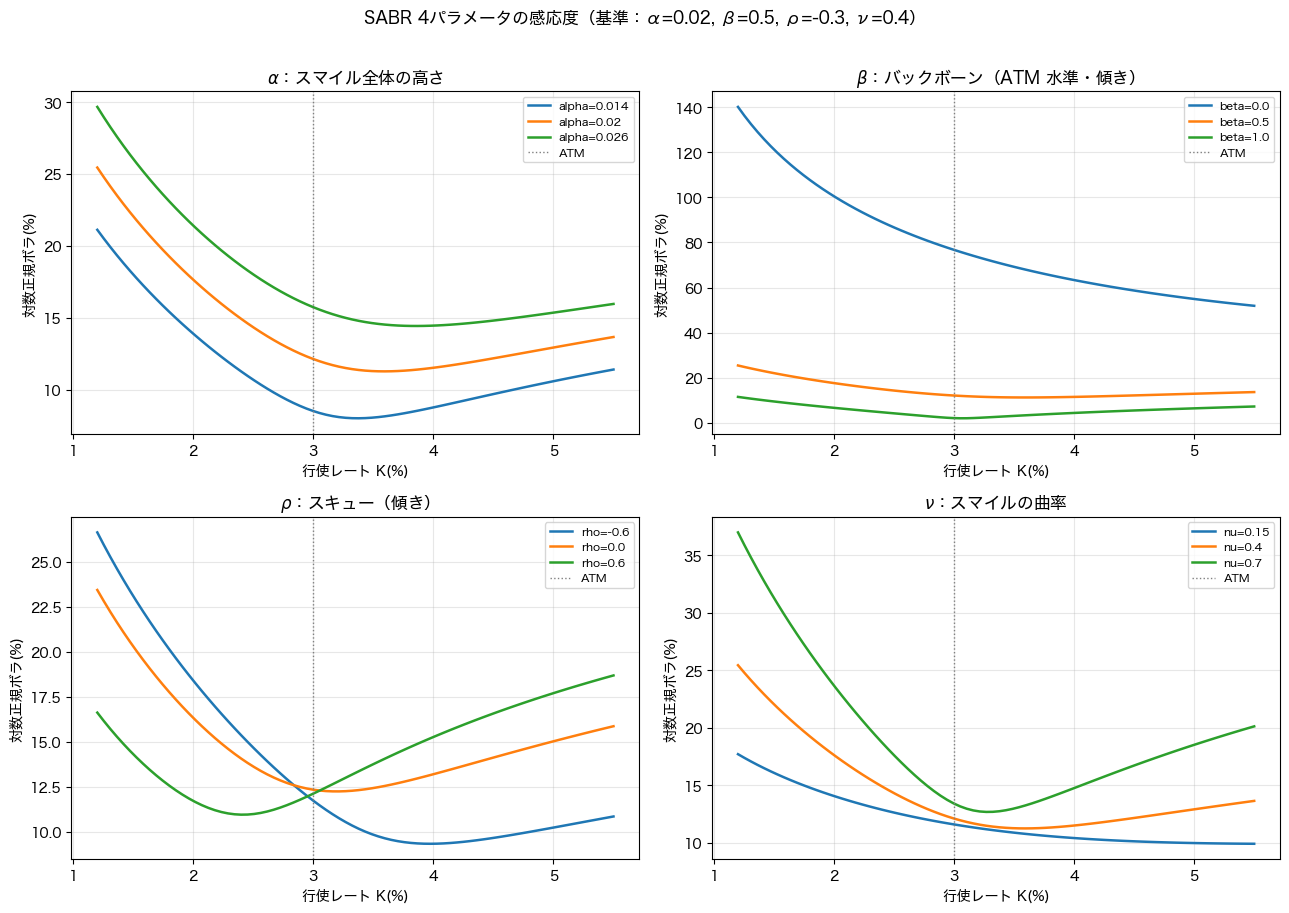

In [3]:
Ks = np.linspace(0.012, 0.055, 80)
base = dict(alpha=0.020, beta=0.5, rho=-0.30, nu=0.40)

grids = {
    "alpha": [0.014, 0.020, 0.026],
    "beta": [0.0, 0.5, 1.0],
    "rho": [-0.6, 0.0, 0.6],
    "nu": [0.15, 0.40, 0.70],
}
titles = {
    "alpha": r"$\alpha$：スマイル全体の高さ",
    "beta": r"$\beta$：バックボーン（ATM 水準・傾き）",
    "rho": r"$\rho$：スキュー（傾き）",
    "nu": r"$\nu$：スマイルの曲率",
}

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, (pname, values) in zip(axes.ravel(), grids.items()):
    for v in values:
        p = dict(base)
        p[pname] = v
        vols = sabr_smile(F, Ks, T, **p) * 100
        ax.plot(Ks * 100, vols, lw=1.8, label=f"{pname}={v}")
    ax.axvline(F * 100, color="gray", ls=":", lw=1, label="ATM")
    ax.set_title(titles[pname])
    ax.set_xlabel("行使レート K(%)")
    ax.set_ylabel("対数正規ボラ(%)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
plt.suptitle("SABR 4パラメータの感応度（基準：α=0.02, β=0.5, ρ=-0.3, ν=0.4）", y=1.01)
plt.tight_layout()
plt.show()

図から読み取れること：

- **$\alpha$**：曲線がほぼ平行に上下します。水準の効きです。
- **$\beta$**：ATM の高さと ATM 近傍の傾きが同時に変わります。$\beta$ が小さいほど
  低ストライク側が持ち上がります（正規的なバックボーン）。
- **$\rho$**：スマイルを回転させます。$\rho<0$ で右下がり、$\rho>0$ で右上がり。
- **$\nu$**：ATM を軸に両裾を持ち上げ、曲率を強めます。

### 既知パラメータからスマイルを生成しフィットで係数復元

$\beta$ を真値に固定し、$(\alpha,\rho,\nu)$ を最小二乗で復元します。$\alpha$ は正、
$\rho$ は $(-1,1)$、$\nu$ は正、という自然な制約を課します。

In [4]:
def fit_sabr(F, Ks, vols, T, beta):
    """観測スマイル(Ks, vols)へ beta 固定で (alpha, rho, nu) を最小二乗フィット。

    返り値は (alpha, rho, nu) と RMSE(bp)。alpha>0, rho in (-1,1), nu>0 を課す。
    初期 alpha は ATM ボラ×F^{1-beta} で与える。
    """
    Ks = np.asarray(Ks, dtype=float)
    vols = np.asarray(vols, dtype=float)
    atm_idx = int(np.argmin(np.abs(Ks - F)))
    alpha0 = vols[atm_idx] * F ** (1 - beta)

    def resid(p):
        a, r, n = p
        model = np.array([my_sabr_vol(F, float(K), T, a, beta, r, n) for K in Ks])
        return (model - vols) * 1e4  # bp 単位で残差

    fit = least_squares(
        resid, x0=[alpha0, -0.2, 0.3],
        bounds=([1e-6, -0.999, 1e-6], [1.0, 0.999, 3.0]),
    )
    rmse = float(np.sqrt(np.mean(fit.fun ** 2)))
    return tuple(fit.x), rmse


# 真値でスマイルを生成（観測データの代役）
obs_Ks = np.array([0.015, 0.020, 0.025, 0.030, 0.035, 0.040, 0.045])
obs_vols = sabr_smile(F, obs_Ks, T, alpha_t, beta_t, rho_t, nu_t)

(alpha_hat, rho_hat, nu_hat), rmse_bp = fit_sabr(F, obs_Ks, obs_vols, T, beta=beta_t)

recover = pd.DataFrame(
    {"真値": [alpha_t, rho_t, nu_t], "復元値": [alpha_hat, rho_hat, nu_hat]},
    index=["alpha", "rho", "nu"],
)
recover["絶対誤差"] = (recover["復元値"] - recover["真値"]).abs()
display(recover)
print(f"\nフィット RMSE = {rmse_bp:.4f} bp")
assert rmse_bp < 1e-2
assert np.allclose([alpha_hat, rho_hat, nu_hat], [alpha_t, rho_t, nu_t], atol=1e-4)
print("既知パラメータをフィットで復元できました（β 固定・3パラメータ）")

,真値,復元値,絶対誤差
alpha,0.02,0.02,0.000000e+00
rho,-0.30,-0.30,2.775558e-16
nu,0.40,0.40,1.110223e-16



フィット RMSE = 0.0000 bp
既知パラメータをフィットで復元できました（β 固定・3パラメータ）


## QuantLib 検証

`bondlab.pricing.sabr_vol` と QuantLib の `ql.sabrVolatility` が機械精度で一致する
ことを確認します。**引数の順番が異なる**点に注意します。

```
bondlab.pricing.sabr_vol(forward, strike, expiry, alpha, beta, rho, nu)
ql.sabrVolatility(strike, forward, expiry, alpha, beta, nu, rho)   # nu と rho が逆順
```

In [5]:
import QuantLib as ql

print("QuantLib version:", ql.__version__)

test_rows = []
rng = np.random.default_rng(1)
for _ in range(200):
    Fx = float(rng.uniform(0.01, 0.06))
    Kx = float(rng.uniform(0.005, 0.08))
    Tx = float(rng.uniform(0.25, 10.0))
    ax = float(rng.uniform(0.005, 0.05))
    bx = float(rng.uniform(0.1, 0.9))
    rx = float(rng.uniform(-0.7, 0.7))
    nx = float(rng.uniform(0.05, 0.8))
    v_bond = sabr_vol(Fx, Kx, Tx, ax, bx, rx, nx)
    v_ql = ql.sabrVolatility(Kx, Fx, Tx, ax, bx, nx, rx)  # 引数順に注意
    test_rows.append(abs(v_bond - v_ql))

max_abs_diff = max(test_rows)
print(f"ランダム 200 ケースの最大絶対差 = {max_abs_diff:.3e}")
assert max_abs_diff < 1e-12
print("bondlab.pricing.sabr_vol == ql.sabrVolatility（機械精度一致）")

QuantLib version: 1.42.1
ランダム 200 ケースの最大絶対差 = 6.994e-15
bondlab.pricing.sabr_vol == ql.sabrVolatility（機械精度一致）


## 実データ適用

### 合成ボラティリティキューブの生成

実市場データの代わりに、満期×テナーごとに少しずつ異なる SABR パラメータで合成
キューブを作ります。各セルの ATM フォワードとパラメータを表にし、キューブの一部を
スマイルとして可視化します。

In [6]:
expiries = [1.0, 5.0, 10.0]     # 満期（年）
tenors = [2.0, 5.0, 10.0]       # 原スワップのテナー（年）
strike_offsets = np.array([-0.015, -0.010, -0.005, 0.0, 0.005, 0.010, 0.015])


def cube_params(expiry, tenor):
    """満期×テナーから合成 SABR パラメータと ATM フォワードを決める。"""
    fwd = 0.020 + 0.0015 * tenor + 0.0008 * expiry      # 右上がりのフォワード面
    alpha = 0.018 + 0.0006 * tenor
    beta = 0.5
    rho = -0.35 + 0.01 * expiry                          # 満期が長いほどスキュー緩む
    nu = 0.55 - 0.03 * expiry                            # 満期が長いほど vol-of-vol 減
    return fwd, alpha, beta, rho, nu


cube = {}
rows = []
for e in expiries:
    for t in tenors:
        fwd, a, b, r, n = cube_params(e, t)
        Ks = fwd + strike_offsets
        vols = sabr_smile(fwd, Ks, e, a, b, r, n)
        cube[(e, t)] = dict(fwd=fwd, Ks=Ks, vols=vols, params=(a, b, r, n))
        rows.append({"満期": e, "テナー": t, "ATM F(%)": fwd * 100,
                     "alpha": a, "beta": b, "rho": round(r, 3), "nu": round(n, 3),
                     "ATMボラ(%)": my_sabr_vol(fwd, fwd, e, a, b, r, n) * 100})

cube_df = pd.DataFrame(rows)
display(cube_df)

,満期,テナー,ATM F(%),alpha,beta,rho,nu,ATMボラ(%)
0,1.0,2.0,2.38,0.0192,0.5,-0.34,0.52,12.645099
1,1.0,5.0,2.83,0.0210,0.5,-0.34,0.52,12.683305
2,1.0,10.0,3.58,0.0240,0.5,-0.34,0.52,12.887223
3,5.0,2.0,2.70,0.0192,0.5,-0.30,0.40,12.264478
4,5.0,5.0,3.15,0.0210,0.5,-0.30,0.40,12.418108
5,5.0,10.0,3.90,0.0240,0.5,-0.30,0.40,12.752267
6,10.0,2.0,3.10,0.0192,0.5,-0.25,0.25,11.340187
7,10.0,5.0,3.55,0.0210,0.5,-0.25,0.25,11.589094
8,10.0,10.0,4.30,0.0240,0.5,-0.25,0.25,12.031617


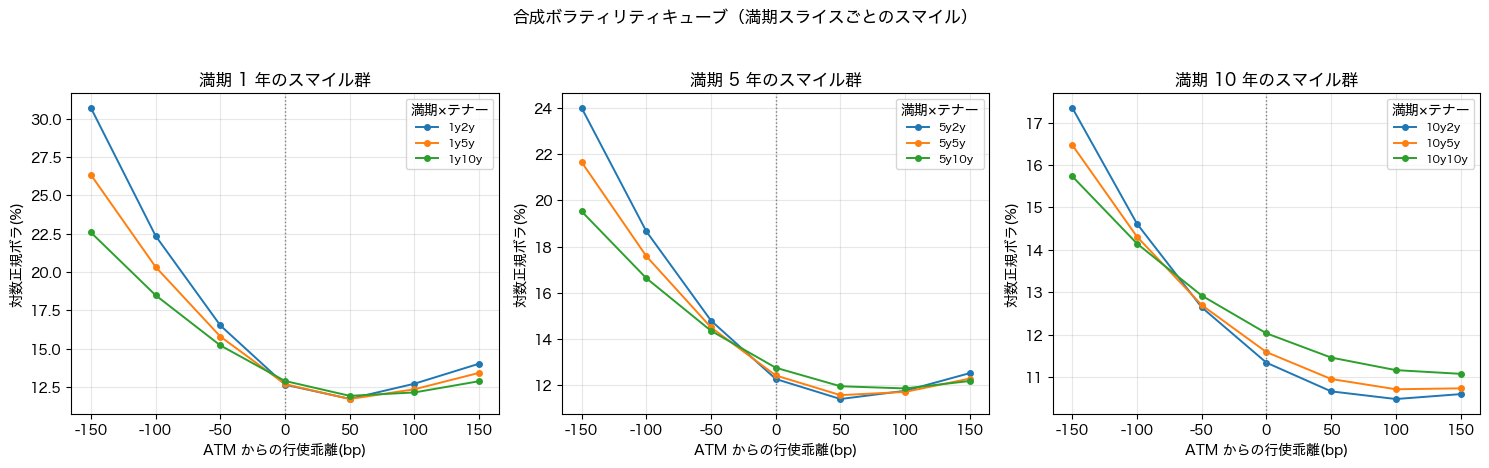

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=False)
for ax, e in zip(axes, expiries):
    for t in tenors:
        c = cube[(e, t)]
        ax.plot((c["Ks"] - c["fwd"]) * 1e4, c["vols"] * 100, "o-", ms=4, lw=1.4,
                label=f"{int(e)}y{int(t)}y")
    ax.axvline(0, color="gray", ls=":", lw=1)
    ax.set_title(f"満期 {int(e)} 年のスマイル群")
    ax.set_xlabel("ATM からの行使乖離(bp)")
    ax.set_ylabel("対数正規ボラ(%)")
    ax.legend(fontsize=8, title="満期×テナー")
    ax.grid(alpha=0.3)
plt.suptitle("合成ボラティリティキューブ（満期スライスごとのスマイル）", y=1.03)
plt.tight_layout()
plt.show()

### $\beta=0$ と $\beta=1$ でフィットしたスマイルの外挿比較

1つのセル（5年満期×10年テナー）を取り出し、キャリブレーション用の狭い行使域
（ATM±50bp）で $\beta=0$ と $\beta=1$ をそれぞれフィットします。次に、その外側
（広い行使域）へ **外挿** して挙動を比べます。狭い域では両者ともほぼ同じ品質で観測に
合いますが、外挿域では $\beta$ の違いが裾の形を大きく変えます。

真の β = 0.5（このセルの生成パラメータ）
β=0 フィット: alpha=0.0047, rho=-0.150, nu=0.368, フィット域RMSE=0.3925bp
β=1 フィット: alpha=0.1237, rho=-0.420, nu=0.443, フィット域RMSE=0.3997bp


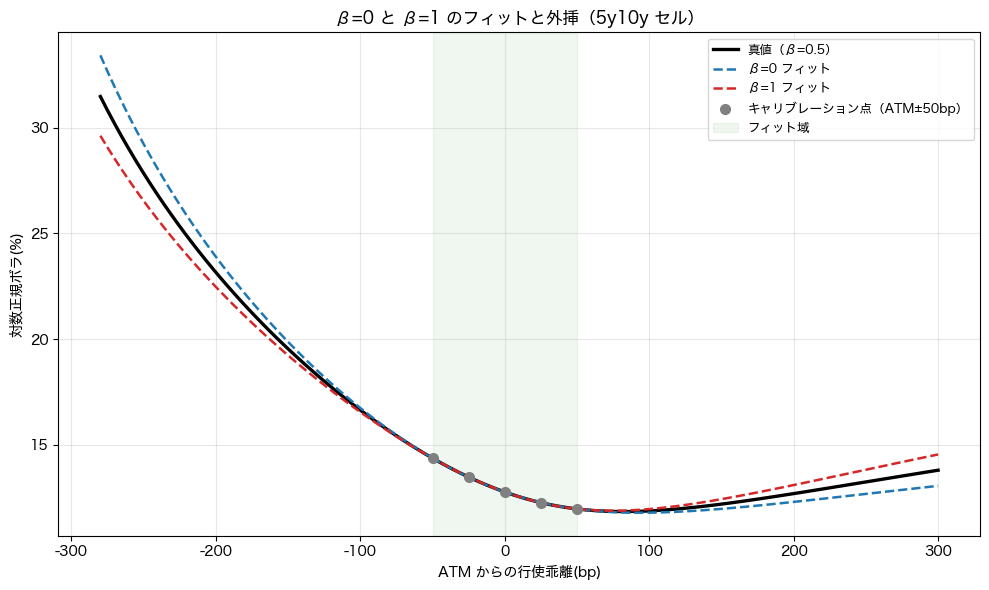

In [8]:
cell = cube[(5.0, 10.0)]
F_c = cell["fwd"]
a0, b0, r0, n0 = cell["params"]

# キャリブレーション域（狭い＝ATM±50bp）と評価域（広い＝外挿を含む）
Ks_calib = F_c + np.linspace(-0.005, 0.005, 5)
vols_calib = sabr_smile(F_c, Ks_calib, 5.0, a0, b0, r0, n0)
Ks_wide = np.linspace(F_c - 0.028, F_c + 0.030, 120)  # 外挿域まで広げる
vols_true_wide = sabr_smile(F_c, Ks_wide, 5.0, a0, b0, r0, n0)

(a_b0, r_b0, n_b0), rmse_b0 = fit_sabr(F_c, Ks_calib, vols_calib, 5.0, beta=0.0)
(a_b1, r_b1, n_b1), rmse_b1 = fit_sabr(F_c, Ks_calib, vols_calib, 5.0, beta=1.0)

fit_b0_wide = sabr_smile(F_c, Ks_wide, 5.0, a_b0, 0.0, r_b0, n_b0)
fit_b1_wide = sabr_smile(F_c, Ks_wide, 5.0, a_b1, 1.0, r_b1, n_b1)

print(f"真の β = {b0}（このセルの生成パラメータ）")
print(f"β=0 フィット: alpha={a_b0:.4f}, rho={r_b0:.3f}, nu={n_b0:.3f}, "
      f"フィット域RMSE={rmse_b0:.4f}bp")
print(f"β=1 フィット: alpha={a_b1:.4f}, rho={r_b1:.3f}, nu={n_b1:.3f}, "
      f"フィット域RMSE={rmse_b1:.4f}bp")

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot((Ks_wide - F_c) * 1e4, vols_true_wide * 100, "k-", lw=2.4,
        label=f"真値（β={b0}）")
ax.plot((Ks_wide - F_c) * 1e4, fit_b0_wide * 100, "--", lw=1.8, color="C0",
        label="β=0 フィット")
ax.plot((Ks_wide - F_c) * 1e4, fit_b1_wide * 100, "--", lw=1.8, color="C3",
        label="β=1 フィット")
ax.plot((Ks_calib - F_c) * 1e4, vols_calib * 100, "o", ms=7, color="gray",
        label="キャリブレーション点（ATM±50bp）")
ax.axvspan(-50, 50, color="green", alpha=0.06, label="フィット域")
ax.set_title("β=0 と β=1 のフィットと外挿（5y10y セル）")
ax.set_xlabel("ATM からの行使乖離(bp)")
ax.set_ylabel("対数正規ボラ(%)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

フィット域（緑帯・ATM±50bp）では $\beta=0$ も $\beta=1$ もほぼ同じ品質で観測に
合います。これは $\beta$ と $\rho$ がどちらもスキューに効くため、$\beta$ を変えても
$\rho$ を調整すれば同じスキューを再現できるからです（**識別問題**）。しかしフィット域の
**外側では両者が乖離** します。$\beta=0$ は低ストライク側で強く持ち上がり、$\beta=1$ は
対数正規的でおとなしい裾になります。外挿の形が $\beta$ に強く依存する、という事実が
次の実務判断につながります。

### 実務で $\beta$ を固定する理由

上の結果から、$\beta$ を毎日フリーにキャリブレーションしない理由がわかります。

1. **識別問題（identification problem）**：$\beta$ と $\rho$ はどちらもスキューを
   動かすため、狭い行使域の観測からは両者を分離できません。同時フィットすると解が
   不安定になり、日々パラメータが跳ねます（ヘッジ係数のノイズ源）。
2. **外挿の安定性**：フィット域では区別できない $\beta$ が、裾の外挿を大きく変えます。
   毎日 $\beta$ が動くと、観測が無いストライクの値付けが日替わりで揺れます。
3. **バックボーンは資産クラスの性質**：$\beta$ は「$F$ が動いたとき ATM ボラがどう
   動くか」という時系列的な性質で、1日のスマイル断面ではなく履歴から決まります。
   金利では慣行的に $\beta=0.5$（あるいは低金利で $\beta=0$）を固定し、$(\alpha,\rho,\nu)$
   だけを日々キャリブレーションします。$\alpha$ を ATM ボラに合わせ、$\rho$ でスキュー、
   $\nu$ で曲率を取る、という役割分担が明確になります。

### 補足：Hagan 近似が壊れる領域（無裁定の破れ）

低金利かつワイドな行使で、Hagan 対数正規スマイルが無裁定を破ることを確認します。
Breeden–Litzenberger の関係
$$
q(K)=\frac{\partial^2 C(K)}{\partial K^2}
$$
でリスク中立密度 $q(K)$ を数値微分すると、健全なスマイルなら $q(K)\ge 0$ です。低い
フォワードで裾まで評価すると $q(K)<0$ の領域（バタフライ・アービトラージ）が現れます。

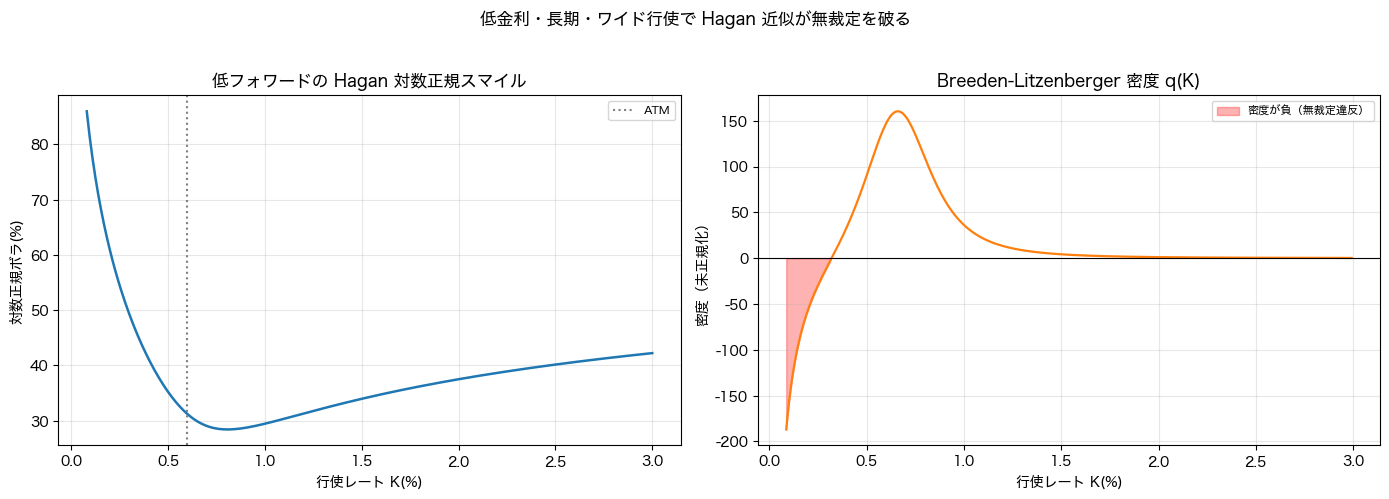

密度が負になる行使が存在するか: True
負density の行使レンジ: 0.087% 〜 0.314%
→ 低金利では素の対数正規 Hagan は破綻する。シフト付き／正規 SABR が実務解


In [9]:
def bl_density(F, Ks, T, vol_fn, df=1.0):
    """Breeden-Litzenberger でリスク中立密度 q(K)=d^2C/dK^2 を中心差分で算出。

    vol_fn(K) が各行使の対数正規ボラを返す。Black'76 でコール価格を作り二階微分する。
    """
    Ks = np.asarray(Ks, dtype=float)
    calls = np.array([black76(F, float(K), T, vol_fn(float(K)), df, "call") for K in Ks])
    dK = Ks[1] - Ks[0]
    return (calls[2:] - 2 * calls[1:-1] + calls[:-2]) / dK ** 2, Ks[1:-1]


# 低フォワード・長期・β=0.5 の素の Hagan 対数正規スマイル
F_low, T_low = 0.006, 10.0
a_low, b_low, r_low, n_low = 0.020, 0.5, -0.30, 0.60
K_dense = np.linspace(0.0008, 0.030, 400)


def vol_fn_low(K):
    return my_sabr_vol(F_low, K, T_low, a_low, b_low, r_low, n_low)


density, K_mid = bl_density(F_low, K_dense, T_low, vol_fn_low)
neg_mask = density < 0

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
axes[0].plot(K_dense * 100, [vol_fn_low(k) * 100 for k in K_dense], lw=1.8)
axes[0].axvline(F_low * 100, color="gray", ls=":", label="ATM")
axes[0].set_title("低フォワードの Hagan 対数正規スマイル")
axes[0].set_xlabel("行使レート K(%)")
axes[0].set_ylabel("対数正規ボラ(%)")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].plot(K_mid * 100, density, lw=1.6, color="C1")
axes[1].axhline(0, color="k", lw=0.8)
if neg_mask.any():
    axes[1].fill_between(K_mid * 100, density, 0, where=neg_mask,
                         color="red", alpha=0.3, label="密度が負（無裁定違反）")
axes[1].set_title("Breeden-Litzenberger 密度 q(K)")
axes[1].set_xlabel("行使レート K(%)")
axes[1].set_ylabel("密度（未正規化）")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)
plt.suptitle("低金利・長期・ワイド行使で Hagan 近似が無裁定を破る", y=1.03)
plt.tight_layout()
plt.show()

print(f"密度が負になる行使が存在するか: {bool(neg_mask.any())}")
print(f"負density の行使レンジ: "
      f"{K_mid[neg_mask].min()*100:.3f}% 〜 {K_mid[neg_mask].max()*100:.3f}%"
      if neg_mask.any() else "（この設定では無し）")
print("→ 低金利では素の対数正規 Hagan は破綻する。シフト付き／正規 SABR が実務解")

## 演習

1. **4パラメータの感応度を1つずつ図示する。** 基準を
   $(\alpha,\beta,\rho,\nu)=(0.02,\,0.5,\,-0.3,\,0.4)$、$F=0.03$、$T=5$ とし、各
   パラメータを単独で3水準動かした4枚のスマイルを描け。さらに ATM ボラの
   バックボーン（$F$ を $0.01\to0.05$ に動かしたときの ATM ボラの軌跡）を
   $\beta\in\{0,0.5,1\}$ について描き、$\beta$ が「$F$ の変化に対する ATM ボラの
   動き方」を決めることを数値で確認せよ。
2. **$\beta=0$ と $\beta=1$ のフィットと外挿、$\beta$ の識別問題。** 真値
   $\beta=0.5$ のスマイルを狭い行使域で生成し、$\beta=0$ と $\beta=1$ で
   $(\alpha,\rho,\nu)$ をフィットせよ。(a) フィット域内の RMSE が両者でほぼ等しい
   こと（識別できないこと）、(b) 外挿域では乖離すること、(c) フィット済み $\rho$ が
   $\beta$ によって系統的にずれること（スキューを $\beta$ と $\rho$ で奪い合うこと）を
   示せ。

解答例は `solutions/S6/sol_0605.py` に置く。

## 用語集

定義の正は `glossary/06_derivatives.md`。ここでは初出語の一行要約のみ示す。

| 用語 | 英語 | 一行定義 |
|---|---|---|
| [SABR](../../glossary/06_derivatives.md#sabr-stochastic-alpha-beta-rho) | SABR (Stochastic Alpha Beta Rho) | フォワードと確率ボラを同時に動かすスマイルモデル。4パラメータ |
| [スマイル](../../glossary/06_derivatives.md#volatility-smile) | volatility smile | 行使に対しインプライドボラが ATM を谷に持ち上がる曲率成分 |
| [スキュー](../../glossary/06_derivatives.md#volatility-skew) | volatility skew | ATM 近傍でのスマイルの傾き。分布の非対称性を表す |
| [ボラティリティキューブ](../../glossary/06_derivatives.md#volatility-cube) | volatility cube | 満期×テナー×ストライクにボラを並べた三次元の格子 |
| [Hagan近似](../../glossary/06_derivatives.md#hagan-s-approximation) | Hagan's approximation | SABR を Black のインプライドボラへ写す漸近展開式 |